In [ ]:
#!pip install matplotlib

In [1]:
import numpy as np
import time
import torch
import time
import sys
import scipy
import matplotlib.pyplot as plt
from scipy import signal
# Generate Networks
import networkx as nx
from scipy.stats import nbinom
import secrets

## Kuramoto Model

# Some other functions

TEST BUG: VARYING FREQ SPREAD


In [2]:
import gc
import torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    alloc = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    print(f"GPU allocated: {alloc:.2f} GB")
    print(f"GPU reserved:  {reserved:.2f} GB")
else:
    print("CUDA not available")

GPU allocated: 0.00 GB
GPU reserved:  0.00 GB


In [3]:
treatment_names_low = [
    "LL",
    "LH",    
    "Watts–Strogatz Low mean",
    "Erdős–Rényi Low mean",
    "Barabási–Albert Low mean",
    ]

treatment_names_high = [    
    "HL",
    "HH",
    "Watts–Strogatz High mean",
    "Erdős–Rényi High mean",
    "Barabási–Albert High mean",
    ]

In [4]:
import numpy as np
import matplotlib.pyplot as plt
#
#data = np.load("results_networks_0_to_117June26.npz", allow_pickle=True)
data = np.load("results_final_0_to_11_final_forever.npz", allow_pickle=True)

VISUALIZATION 1. TOTAL

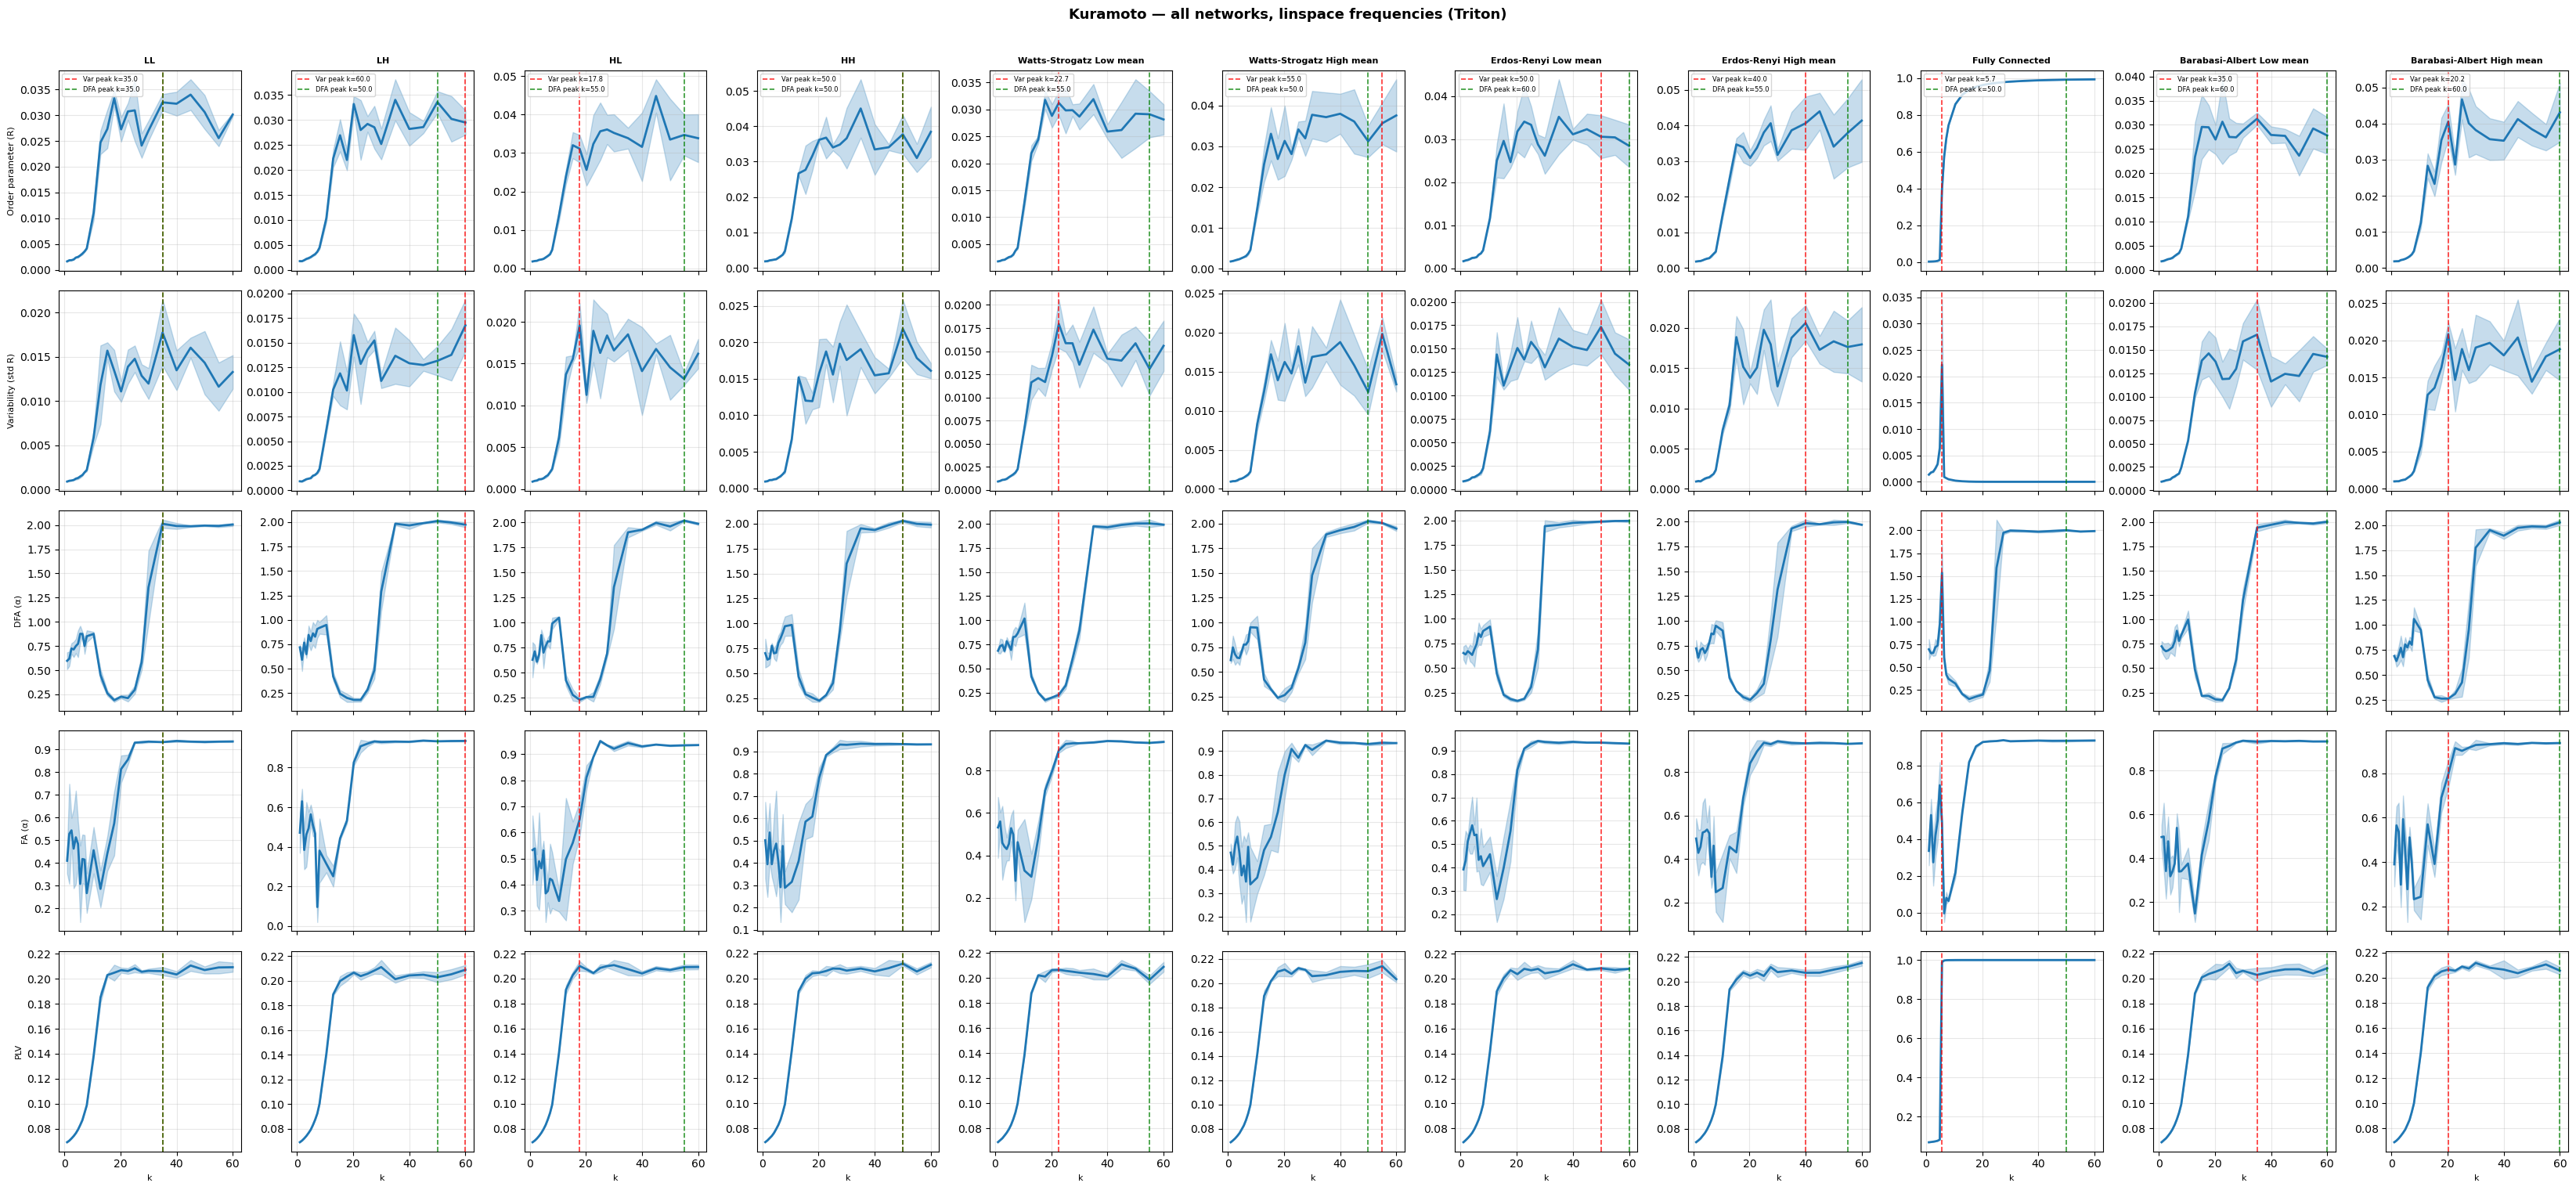

In [6]:
order_matrix       = data["order_matrix"]
variability_matrix = data["variability_matrix"]
plv_matrix         = data["plv_matrix"]
dfa_matrix         = data["dfa_matrix"]
fa_matrix          = data["fa_matrix"]
k_values           = data["k_values"]
network_names      = list(data["network_names"])

# Drop duplicate k-value boundary points
_, unique_idx = np.unique(k_values, return_index=True)
k = k_values[unique_idx]

def trim(m):
    return m[:, :, unique_idx]

order       = trim(order_matrix)
variability = trim(variability_matrix)
plv         = trim(plv_matrix)
dfa         = trim(dfa_matrix)
fa          = trim(fa_matrix)

metrics      = [order, variability, dfa, fa, plv]
metric_names = ["Order parameter (R)", "Variability (std R)", "DFA (α)", "FA (α)", "PLV"]

# ── Plot 1 — all networks, all metrics ────────────────────────────────────────
fig, axs = plt.subplots(len(metric_names), len(network_names),
                        figsize=(3 * len(network_names), 3 * len(metric_names)),
                        sharex=True)

for col, net_name in enumerate(network_names):
    # Compute critical points once per network column
    var_mean      = variability[col].mean(axis=0)
    dfa_mean      = dfa[col].mean(axis=0)
    k_var_peak    = k[np.argmax(var_mean)]   # variability peak → k_crit
    k_dfa_peak    = k[np.argmax(dfa_mean)]   # DFA peak

    for row, (name, mat) in enumerate(zip(metric_names, metrics)):
        ax   = axs[row, col]
        mean = mat[col].mean(axis=0)
        std  = mat[col].std(axis=0)

        ax.plot(k, mean, linewidth=2, color="tab:blue")
        ax.fill_between(k, mean - std, mean + std, alpha=0.25, color="tab:blue")

        # Vertical lines on every subplot
        ax.axvline(k_var_peak, color="red",   linestyle="--", linewidth=1.2,
                   alpha=0.8, label=f"Var peak k={k_var_peak:.1f}")
        ax.axvline(k_dfa_peak, color="green", linestyle="--", linewidth=1.2,
                   alpha=0.8, label=f"DFA peak k={k_dfa_peak:.1f}")

        # Show legend only on top row to avoid clutter
        if row == 0:
            ax.legend(fontsize=6, loc="upper left")

        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(net_name, fontsize=8, fontweight="bold")
        if col == 0:
            ax.set_ylabel(name, fontsize=8)
        if row == len(metric_names) - 1:
            ax.set_xlabel("k", fontsize=8)

plt.suptitle("Kuramoto — all networks, linspace frequencies (Triton)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_all_networks FINALJuly.png", dpi=300, bbox_inches="tight")
plt.show()




UNTIL K = 30

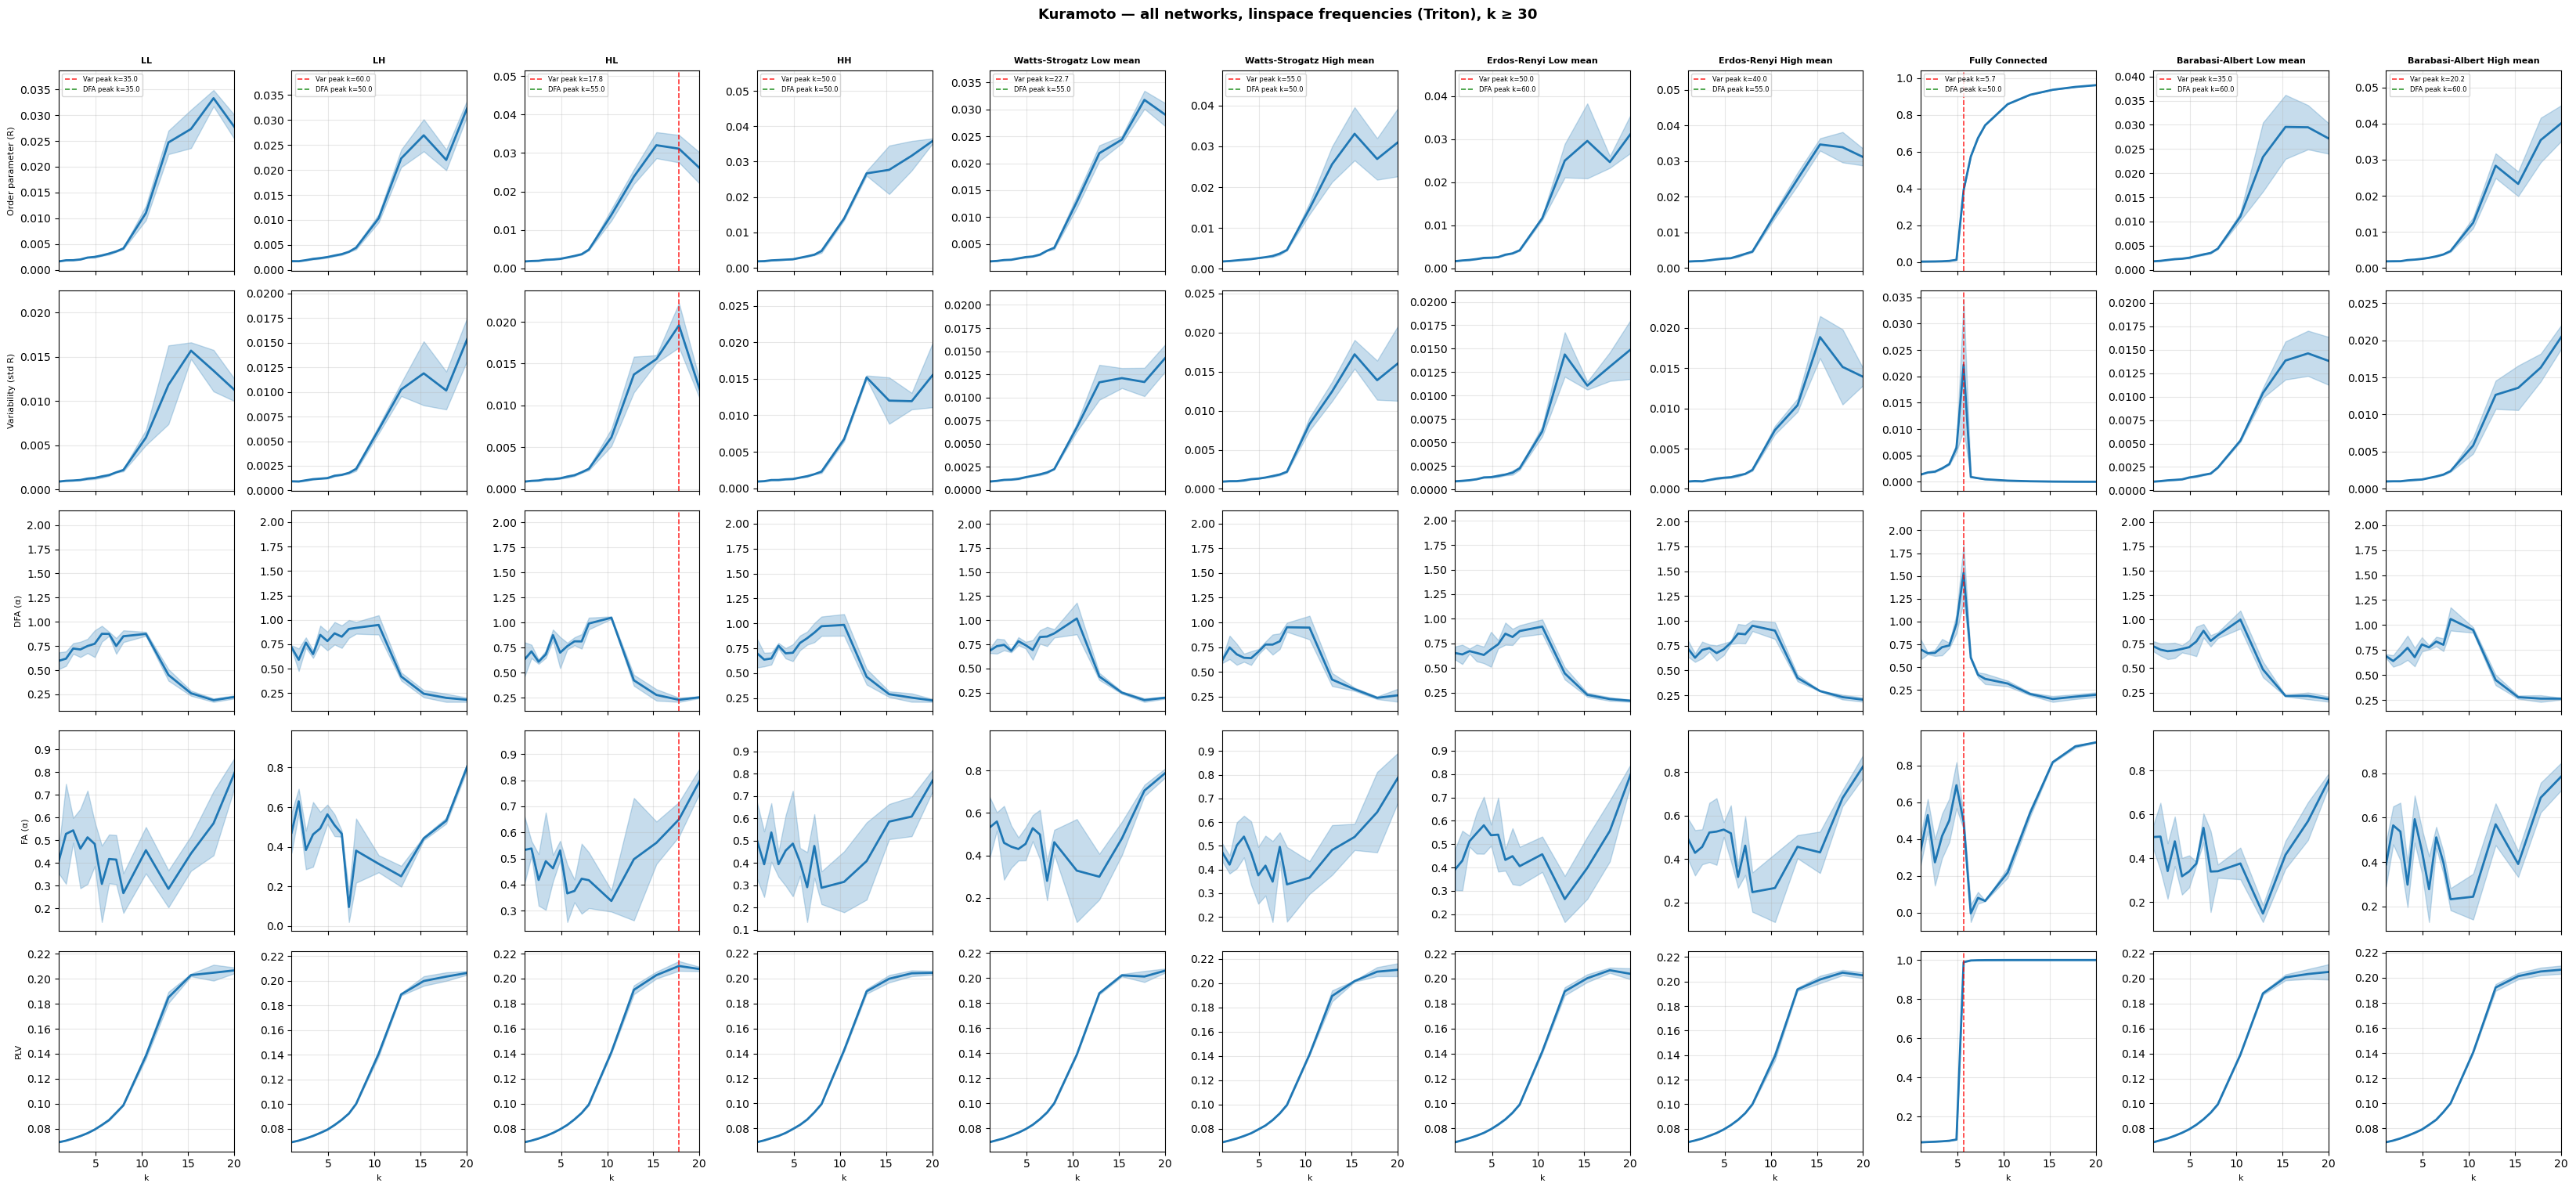

In [7]:
order_matrix       = data["order_matrix"]
variability_matrix = data["variability_matrix"]
plv_matrix         = data["plv_matrix"]
dfa_matrix         = data["dfa_matrix"]
fa_matrix          = data["fa_matrix"]
k_values           = data["k_values"]
network_names      = list(data["network_names"])

# Drop duplicate k-value boundary points
_, unique_idx = np.unique(k_values, return_index=True)
k = k_values[unique_idx]

def trim(m):
    return m[:, :, unique_idx]

order       = trim(order_matrix)
variability = trim(variability_matrix)
plv         = trim(plv_matrix)
dfa         = trim(dfa_matrix)
fa          = trim(fa_matrix)

metrics      = [order, variability, dfa, fa, plv]
metric_names = ["Order parameter (R)", "Variability (std R)", "DFA (α)", "FA (α)", "PLV"]

K_MIN = 30  # <-- new: lower bound for x-axis

# ── Plot 1 — all networks, all metrics ────────────────────────────────────────
fig, axs = plt.subplots(len(metric_names), len(network_names),
                        figsize=(3 * len(network_names), 3 * len(metric_names)),
                        sharex=True)

for col, net_name in enumerate(network_names):
    # Compute critical points once per network column (using FULL k range)
    var_mean      = variability[col].mean(axis=0)
    dfa_mean      = dfa[col].mean(axis=0)
    k_var_peak    = k[np.argmax(var_mean)]   # variability peak → k_crit
    k_dfa_peak    = k[np.argmax(dfa_mean)]   # DFA peak

    for row, (name, mat) in enumerate(zip(metric_names, metrics)):
        ax   = axs[row, col]
        mean = mat[col].mean(axis=0)
        std  = mat[col].std(axis=0)

        ax.plot(k, mean, linewidth=2, color="tab:blue")
        ax.fill_between(k, mean - std, mean + std, alpha=0.25, color="tab:blue")

        # Vertical lines on every subplot
        ax.axvline(k_var_peak, color="red",   linestyle="--", linewidth=1.2,
                   alpha=0.8, label=f"Var peak k={k_var_peak:.1f}")
        ax.axvline(k_dfa_peak, color="green", linestyle="--", linewidth=1.2,
                   alpha=0.8, label=f"DFA peak k={k_dfa_peak:.1f}")

        ax.set_xlim(1, 20)  # <-- new: restrict x-axis to k >= 30

        # Show legend only on top row to avoid clutter
        if row == 0:
            ax.legend(fontsize=6, loc="upper left")

        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(net_name, fontsize=8, fontweight="bold")
        if col == 0:
            ax.set_ylabel(name, fontsize=8)
        if row == len(metric_names) - 1:
            ax.set_xlabel("k", fontsize=8)

plt.suptitle("Kuramoto — all networks, linspace frequencies (Triton), k ≥ 30",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_all_networks_KURAMOTO.png", dpi=150, bbox_inches="tight")
plt.show()

NEW marks for the peaks

HERE IT iS THE FINAL PICTURE

FOR PRINTING

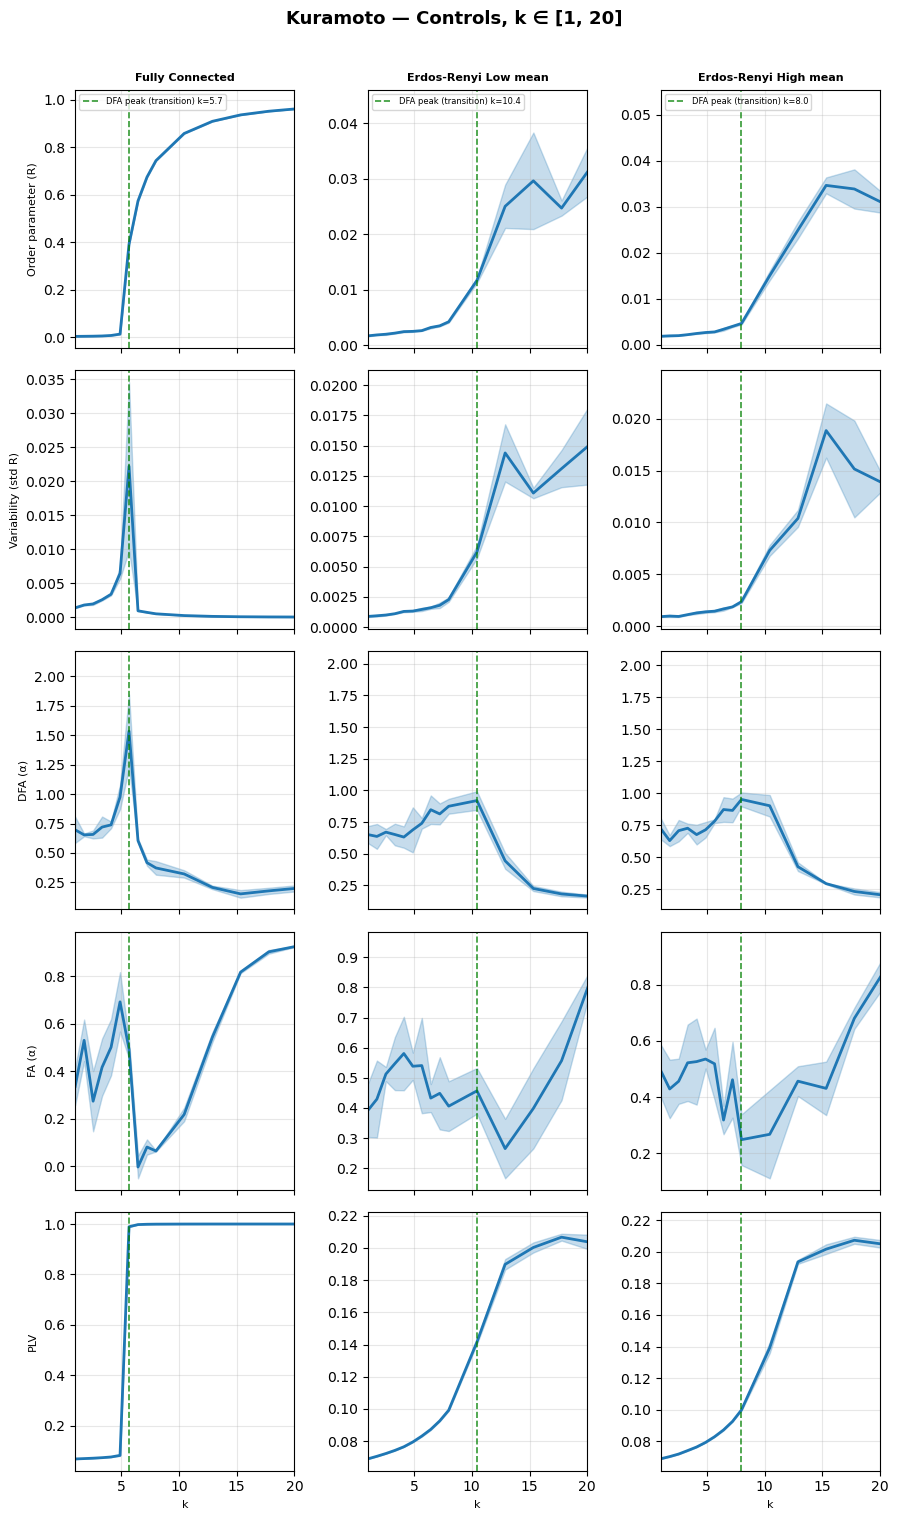

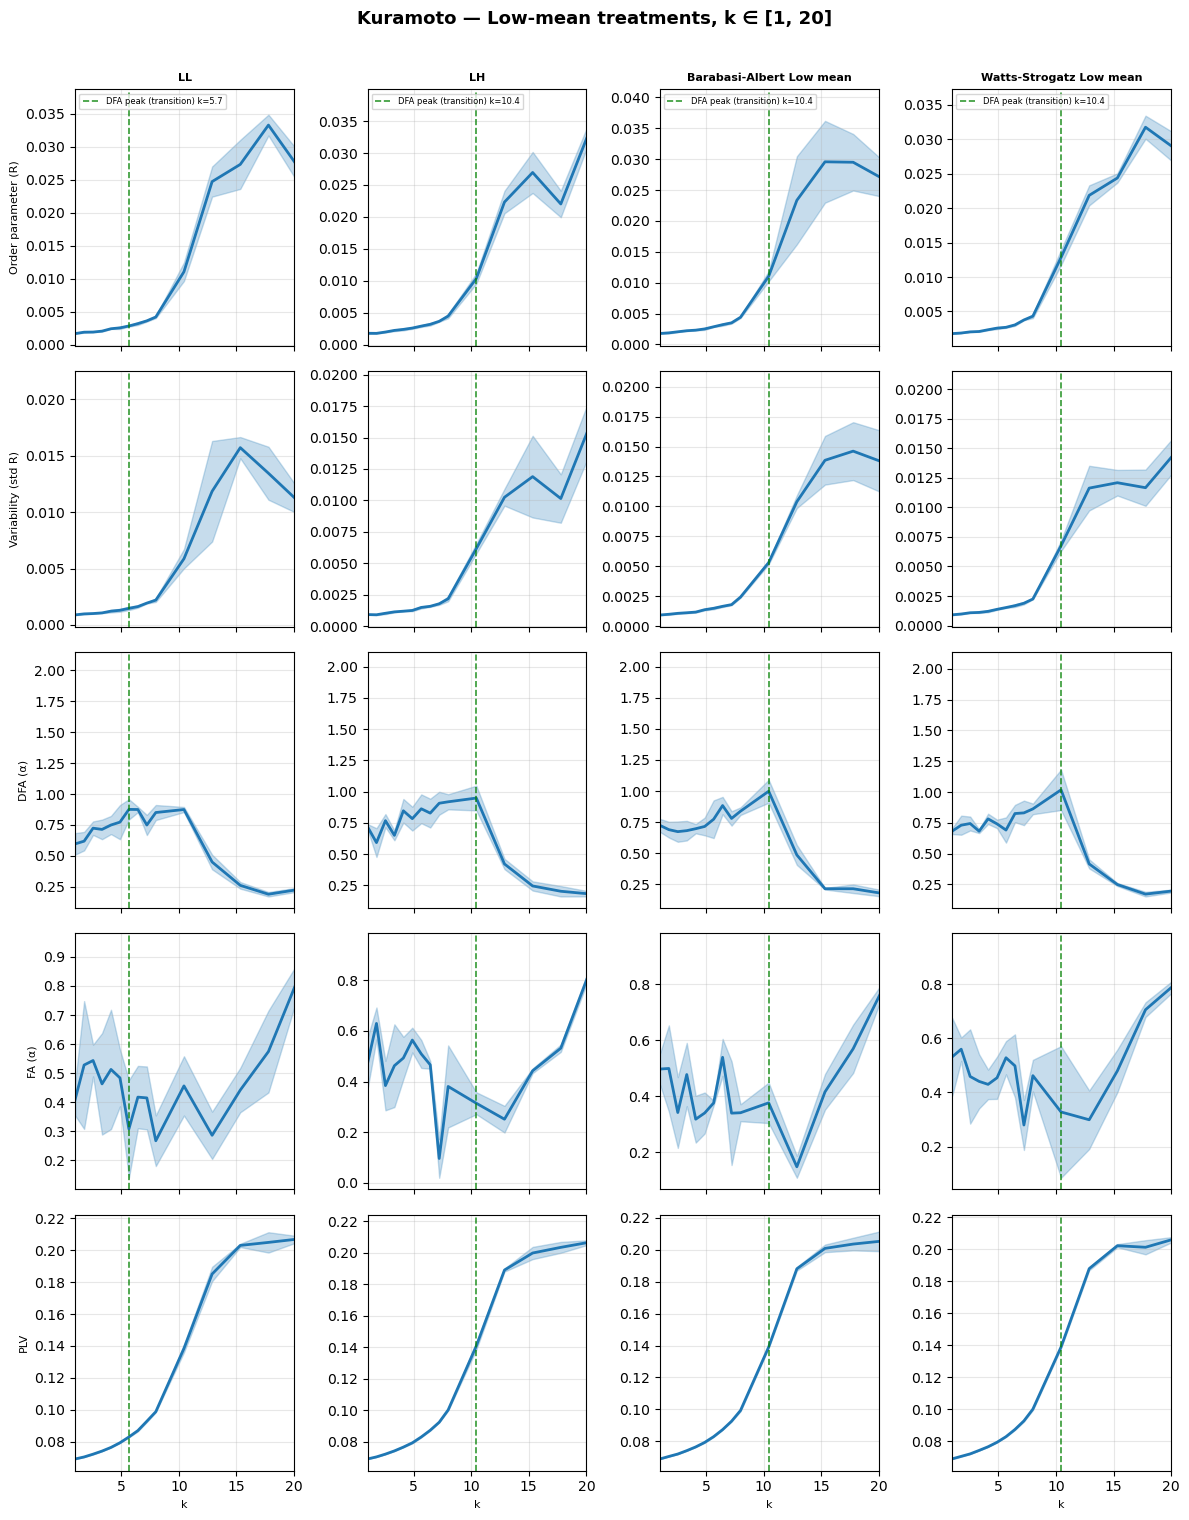

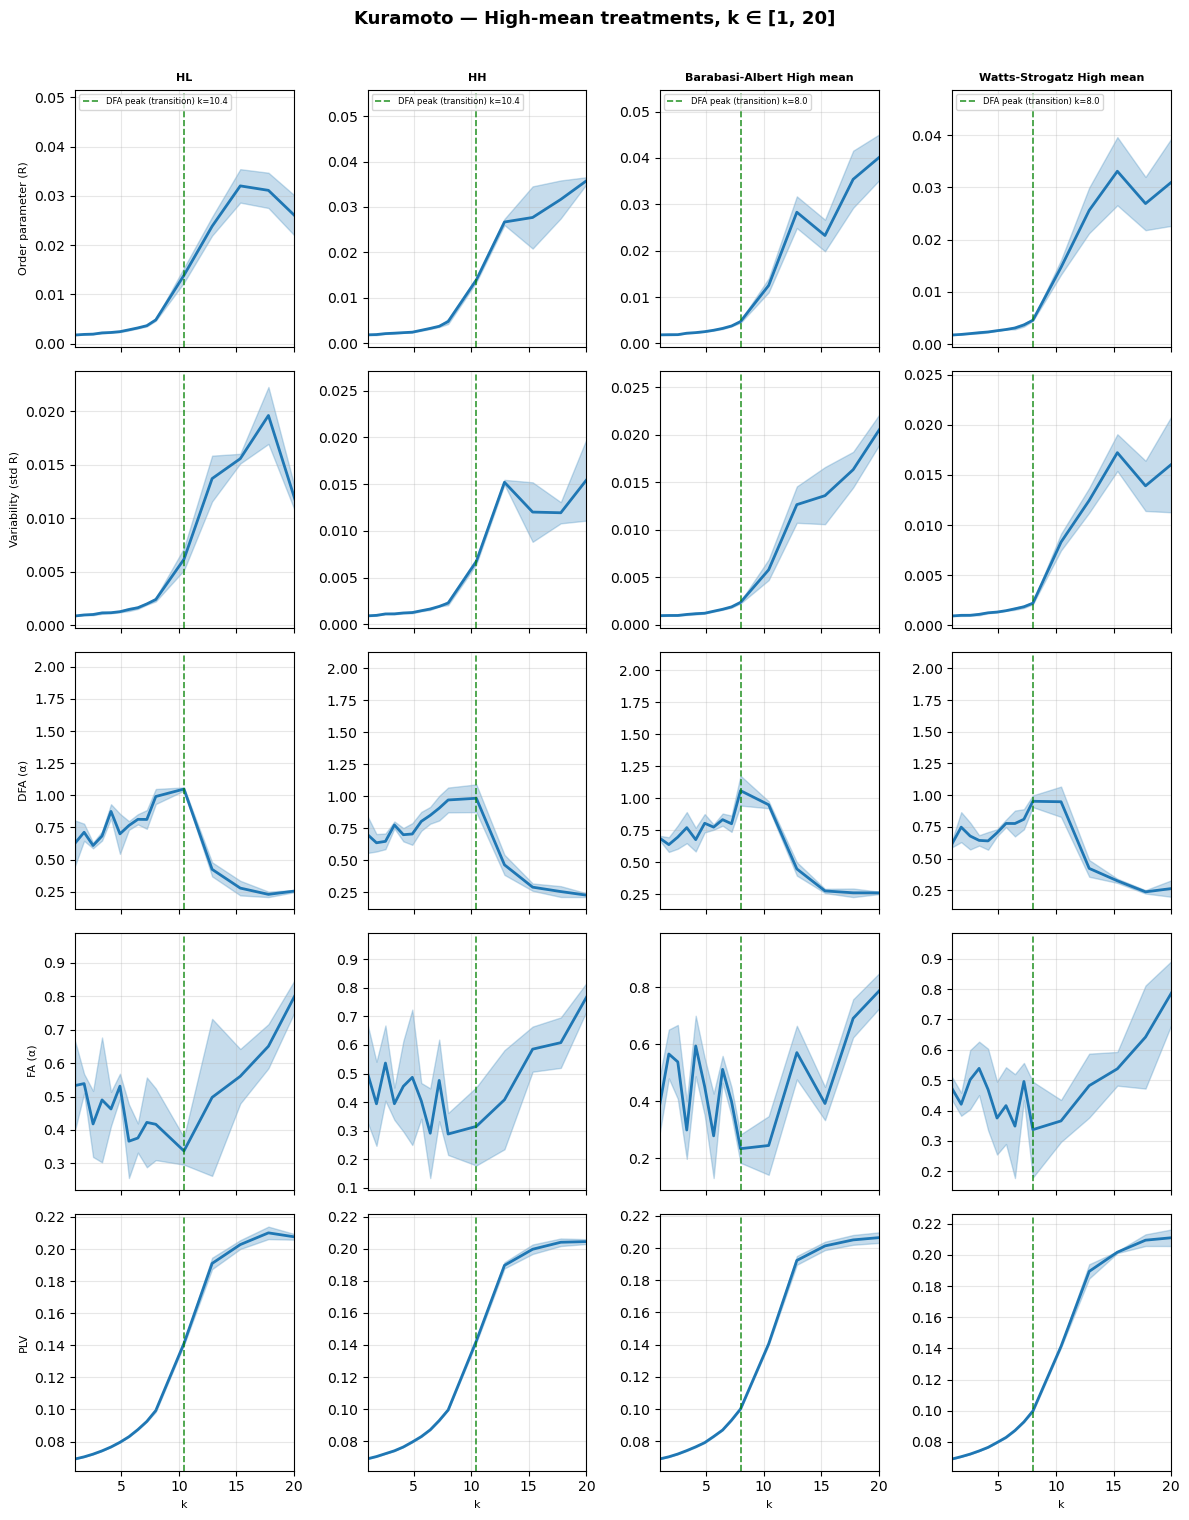

In [9]:
# ── Split the all-networks grid into three thesis pages ───────────────────────
page_groups = [
    # Page 1 — Controls: Fully Connected + Erdos-Renyi (both means)
    ("Controls",
     ["Fully Connected", "Erdos-Renyi Low mean", "Erdos-Renyi High mean"],
     "plot_page1_controls.png"),

    # Page 2 — Low-mean treatments
    ("Low-mean treatments",
     ["LL", "LH", "Barabasi-Albert Low mean", "Watts-Strogatz Low mean"],
     "plot_page2_low.png"),

    # Page 3 — High-mean treatments
    ("High-mean treatments",
     ["HL", "HH", "Barabasi-Albert High mean", "Watts-Strogatz High mean"],
     "plot_page3_high.png"),
]


def plot_page(selected_names, page_title, filename):
    # Resolve requested names to their column indices in network_names
    cols = []
    for nm in selected_names:
        if nm in network_names:
            cols.append(network_names.index(nm))
        else:
            print(f"⚠ '{nm}' not found in network_names — skipped")
    if not cols:
        print(f"⚠ no valid networks for page '{page_title}' — skipping")
        return

    fig, axs = plt.subplots(len(metric_names), len(cols),
                            figsize=(3 * len(cols), 3 * len(metric_names)),
                            sharex=True, squeeze=False)

    for j, col in enumerate(cols):
        # DFA peak within the k window marks the transition
        dfa_mean = dfa[col].mean(axis=0)[k_mask]
        k_dfa_peak = k_window[np.argmax(dfa_mean)]

        for row, (name, mat) in enumerate(zip(metric_names, metrics)):
            ax   = axs[row, j]
            mean = mat[col].mean(axis=0)
            std  = mat[col].std(axis=0)

            ax.plot(k, mean, linewidth=2, color="tab:blue")
            ax.fill_between(k, mean - std, mean + std, alpha=0.25, color="tab:blue")

            # DFA peak marks the transition — drawn on every subplot
            ax.axvline(k_dfa_peak, color="green", linestyle="--", linewidth=1.2,
                       alpha=0.8, label=f"DFA peak (transition) k={k_dfa_peak:.1f}")

            ax.set_xlim(K_MIN, K_MAX)
            if row == 0:
                ax.legend(fontsize=6, loc="upper left")
            ax.grid(True, alpha=0.3)
            if row == 0:
                ax.set_title(network_names[col], fontsize=8, fontweight="bold")
            if j == 0:
                ax.set_ylabel(name, fontsize=8)
            if row == len(metric_names) - 1:
                ax.set_xlabel("k", fontsize=8)

    plt.suptitle(f"Kuramoto — {page_title}, k ∈ [{K_MIN}, {K_MAX}]",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


for page_title, names, fname in page_groups:
    plot_page(names, page_title, fname)
